In [ ]:
# ================= ANN ARCHITECTURE =================
# Type: Feedforward Neural Network (Fully Connected / Dense)

# Input Layer:
# - Number of features: 8 (from California Housing dataset)

# Hidden Layer 1:
# - Dense layer with 64 neurons
# - Activation function: ReLU

# Hidden Layer 2:
# - Dense layer with 32 neurons
# - Activation function: ReLU

# Output Layer:
# - Dense layer with 1 neuron
# - No activation function (linear output for regression)

# Compilation:
# - Optimizer: Adam
# - Loss Function: Mean Squared Error (MSE)
# - Metric: Mean Absolute Error (MAE)

# Training:
# - Epochs: 50
# - Batch size: 32
# - Validation split: 20%

# Evaluation:
# - Metrics: Test Loss, MAE, R² Score
# ===================================================

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.7970 - mae: 0.6192 - val_loss: 0.5072 - val_mae: 0.4801
Epoch 2/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.4053 - mae: 0.4493 - val_loss: 0.4100 - val_mae: 0.4519
Epoch 3/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3713 - mae: 0.4304 - val_loss: 0.3941 - val_mae: 0.4389
Epoch 4/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3578 - mae: 0.4193 - val_loss: 0.3787 - val_mae: 0.4291
Epoch 5/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3421 - mae: 0.4101 - val_loss: 0.3681 - val_mae: 0.4238
Epoch 6/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3275 - mae: 0.4009 - val_loss: 0.3769 - val_mae: 0.4356
Epoch 7/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3220 - mae: 0.3960 - val_loss: 0.3475 - val_mae: 0.4071
Epoch 8/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3164 - mae: 0.3919 - val_loss: 0.3640 - val_mae: 0.4297
Epoch 9/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - lo

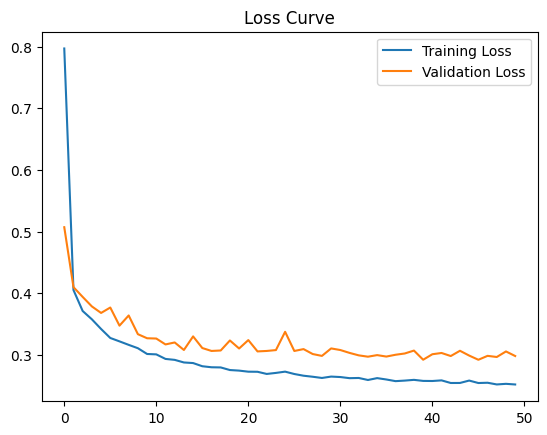

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import r2_score

data = fetch_california_housing()
X = data.data
y = data.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
model = Sequential()

# Input + Hidden layers
model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(32, activation='relu'))

# Output layer (1 neuron for regression)
model.add(Dense(1))
model.compile(
    optimizer='adam',
    loss='mse',   # Mean Squared Error
    metrics=['mae']
)
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)
loss, mae = model.evaluate(X_test, y_test)
print("Test Loss:", loss)
print("Test MAE:", mae)
predictions = model.predict(X_test)

r2 = r2_score(y_test, predictions)
print("R2 Score:", r2)

print("Predicted:", predictions[:5])
print("Actual:", y_test[:5])
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Curve")
plt.show()